In [ ]:
# Imports and Environment Setup
import pandas as pd
import numpy as np
from statsbombpy import sb
import time
import warnings

warnings.filterwarnings('ignore')
print("Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [ ]:
# Cell 2: Extraction and Era Categorization

def assign_manager_era(date_string):
    """Categorizes matches into tactical eras based on historical dates."""
    match_date = pd.to_datetime(date_string)
    if match_date < pd.to_datetime('2008-06-30'): return 'Rijkaard'
    elif match_date < pd.to_datetime('2012-06-30'): return 'Guardiola'
    elif match_date < pd.to_datetime('2014-06-30'): return 'Vilanova/Martino'
    elif match_date < pd.to_datetime('2017-06-30'): return 'Luis Enrique'
    elif match_date < pd.to_datetime('2020-01-13'): return 'Valverde'
    elif match_date < pd.to_datetime('2021-11-06'): return 'Setien/Koeman'
    else: return 'Xavi'

print("Starting Data Extraction...")

comps = sb.competitions()
la_liga_df = comps[comps['competition_id'] == 11]

# Exclude 1973/1974 and 2004/2005 due to tiny sample sizes
seasons_to_exclude = [278, 37]
la_liga_seasons = la_liga_df[~la_liga_df['season_id'].isin(seasons_to_exclude)]['season_id'].tolist()

all_events = []
total_matches = 0

for season in la_liga_seasons:
    try:
        matches = sb.matches(competition_id=11, season_id=season)
        barca_matches = matches[(matches['home_team'] == 'Barcelona') | (matches['away_team'] == 'Barcelona')]
        
        print(f"Season ID {season}: Downloading {len(barca_matches)} Barcelona matches...")
        
        for _, match in barca_matches.iterrows():
            match_id = match['match_id']
            success = False
            retries = 3
            
            # RETRY LOGIC: Try up to 3 times per match if the API drops the connection
            for attempt in range(retries):
                try:
                    events = sb.events(match_id=match_id)
                    
                    # Attach our custom variables
                    events['season_id'] = season
                    events['match_id'] = match_id
                    events['match_date'] = match['match_date']
                    events['manager_era'] = assign_manager_era(match['match_date'])
                    
                    all_events.append(events)
                    total_matches += 1
                    success = True
                    
                    time.sleep(0.5)
                    break # Break out of the retry loop and go to the next match
                    
                except Exception as e:
                    print(f"Timeout on match {match_id}. Retrying... (Attempt {attempt+1}/{retries})")
                    time.sleep(5) # Wait 5 seconds before trying again
            
            if not success:
                print(f"FATAL: Could not download match {match_id} after {retries} attempts.")
                
    except Exception as e:
        print(f"Could not load schedule for season {season}: {e}")

# Combine all seasons into one massive table
raw_df = pd.concat(all_events, ignore_index=True)

# Save to your computer
raw_df.to_pickle("barca_raw_events.pkl")
print(f"\nEXTRACTION COMPLETE! Saved {len(raw_df)} total events to 'barca_raw_events.pkl'.")

🚀 Starting Bulletproof Data Extraction...
Season ID 90: Downloading 35 Barcelona matches...
Season ID 42: Downloading 33 Barcelona matches...
Season ID 4: Downloading 34 Barcelona matches...
Season ID 1: Downloading 36 Barcelona matches...
Season ID 2: Downloading 34 Barcelona matches...
Season ID 27: Downloading 38 Barcelona matches...
Season ID 26: Downloading 38 Barcelona matches...
Season ID 25: Downloading 31 Barcelona matches...
Season ID 24: Downloading 32 Barcelona matches...
Season ID 23: Downloading 37 Barcelona matches...
Season ID 22: Downloading 33 Barcelona matches...
Season ID 21: Downloading 35 Barcelona matches...
Season ID 41: Downloading 31 Barcelona matches...
Season ID 40: Downloading 28 Barcelona matches...
Season ID 39: Downloading 26 Barcelona matches...
Season ID 38: Downloading 17 Barcelona matches...

✅ EXTRACTION COMPLETE! Saved 1954573 total events to 'barca_raw_events.pkl'.


In [ ]:
# Cell 3: Parsing Spatial Coordinates

print("Cleaning nested spatial coordinates...")

# Load the dataset
df = pd.read_pickle("barca_raw_events.pkl")

# Define a function to split the [X, Y] list safely
def extract_coords(loc_list):
    # Check if the data is actually a list with at least 2 numbers
    if isinstance(loc_list, list) and len(loc_list) >= 2:
        return pd.Series([loc_list[0], loc_list[1]])
    # If the event doesn't have a location (like a substitution), leave it blank (NaN)
    return pd.Series([np.nan, np.nan])

# Apply the function to the starting locations of all events
df[['location_x', 'location_y']] = df['location'].apply(extract_coords)

# Apply the function to the ending locations (specifically for passes)
if 'pass_end_location' in df.columns:
    df[['pass_end_location_x', 'pass_end_location_y']] = df['pass_end_location'].apply(extract_coords)

# Save this cleaned version so we don't have to parse it again
df.to_pickle("barca_master_cleaned.pkl")
print(f"✅ SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.")

🧹 Cleaning nested spatial coordinates...
✅ SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.


In [ ]:
# Cell 4: Calculating Capstone Metrics

print("Engineering Tactical Features...")

# 1. Load the cleaned coordinate data
df = pd.read_pickle("barca_master_cleaned.pkl")

# METRIC 1: DEFENSIVE LINE HEIGHT
# Define what counts as a defensive action
def_events = ['Pressure', 'Tackle', 'Interception', 'Block', 'Ball Recovery', 'Foul Committed']

# Filter for only Barcelona's defensive actions
barca_def = df[(df['team'] == 'Barcelona') & (df['type'].isin(def_events))]

# Average the X coordinate of those actions for every single match
def_line = barca_def.groupby(['match_id', 'match_date', 'manager_era'])['location_x'].mean().reset_index()
def_line.rename(columns={'location_x': 'def_line_height'}, inplace=True)

# METRIC 2: PPDA (Passes Per Defensive Action)
# Count opponent passes in their build-up phase (X < 72 for the opponent)
opp_passes = df[(df['team'] != 'Barcelona') & (df['type'] == 'Pass') & (df['location_x'] < 72)]
opp_pass_count = opp_passes.groupby('match_id').size().reset_index(name='opp_passes_allowed')

# Count Barca's defensive actions high up the pitch (X > 48 for Barca)
barca_high_def = barca_def[barca_def['location_x'] > 48]
barca_def_count = barca_high_def.groupby('match_id').size().reset_index(name='high_def_actions')

# Merge the counts and calculate the ratio
ppda_df = pd.merge(opp_pass_count, barca_def_count, on='match_id', how='left')

# If Barca made 0 high defensive actions in a game, we replace it with 1 to prevent a "Divide by Zero" math error
ppda_df['high_def_actions'] = ppda_df['high_def_actions'].fillna(1) 

# Calculate the final PPDA metric
ppda_df['ppda'] = ppda_df['opp_passes_allowed'] / ppda_df['high_def_actions']

# FINAL ANALYTICAL TABLE
# Combine Defensive Line Height and PPDA into one clean table
tactics_df = pd.merge(def_line, ppda_df[['match_id', 'ppda']], on='match_id', how='left')

# Sort chronologically by date
tactics_df = tactics_df.sort_values('match_date').reset_index(drop=True)

# Save the final, lightweight CSV. This will be used for your statistical tests and charts!
tactics_df.to_csv("barcelona_match_tactics.csv", index=False)

print("FEATURE ENGINEERING COMPLETE!")
print("\nPreview of your final Tactical Match Database:")
display(tactics_df.head())

⚙️ Engineering Tactical Features...
✅ FEATURE ENGINEERING COMPLETE!

Preview of your final Tactical Match Database:


,match_id,match_date,manager_era,def_line_height,ppda
0,68317,2005-10-01,Rijkaard,59.529646,1.908451
1,68318,2005-10-22,Rijkaard,55.798039,1.897638
2,69164,2005-10-26,Rijkaard,62.703723,1.552846
3,68339,2005-11-06,Rijkaard,56.946429,2.762295
4,68319,2005-11-19,Rijkaard,55.008027,1.774194


In [ ]:
# Cell 5: Statistical Hypothesis Testing (ANOVA)
import pandas as pd
import scipy.stats as stats

print("Running Statistical ANOVA Tests...\n")
df = pd.read_csv("barcelona_match_tactics.csv").dropna()

# Group the data by our distinct managerial eras
eras = df['manager_era'].unique()

# Test Defensive Line Height
def_height_groups = [df[df['manager_era'] == era]['def_line_height'] for era in eras]
f_stat_def, p_val_def = stats.f_oneway(*def_height_groups)

# Test PPDA (Pressing Intensity)
ppda_groups = [df[df['manager_era'] == era]['ppda'] for era in eras]
f_stat_ppda, p_val_ppda = stats.f_oneway(*ppda_groups)

# Print the Results
print("--- ANOVA RESULTS ---")
print(f"Defensive Line Height: p-value = {p_val_def:.5f}")
if p_val_def < 0.05:
    print("Statistically significant! Managers deployed vastly different defensive heights.")
else:
    print("Not significant. Defensive height remained relatively constant.")

print(f"\nPPDA (Pressing): p-value = {p_val_ppda:.5f}")
if p_val_ppda < 0.05:
    print("Statistically significant! Pressing intensity changed drastically between eras.")
else:
    print("Not significant. Pressing intensity remained relatively constant.")

🔬 Running Statistical ANOVA Tests...

--- ANOVA RESULTS ---
Defensive Line Height: p-value = 0.00107
✅ Statistically significant! Managers deployed vastly different defensive heights.

PPDA (Pressing): p-value = 0.00180
✅ Statistically significant! Pressing intensity changed drastically between eras.


Matplotlib is building the font cache; this may take a moment.


📈 Generating Tactical Timelines...


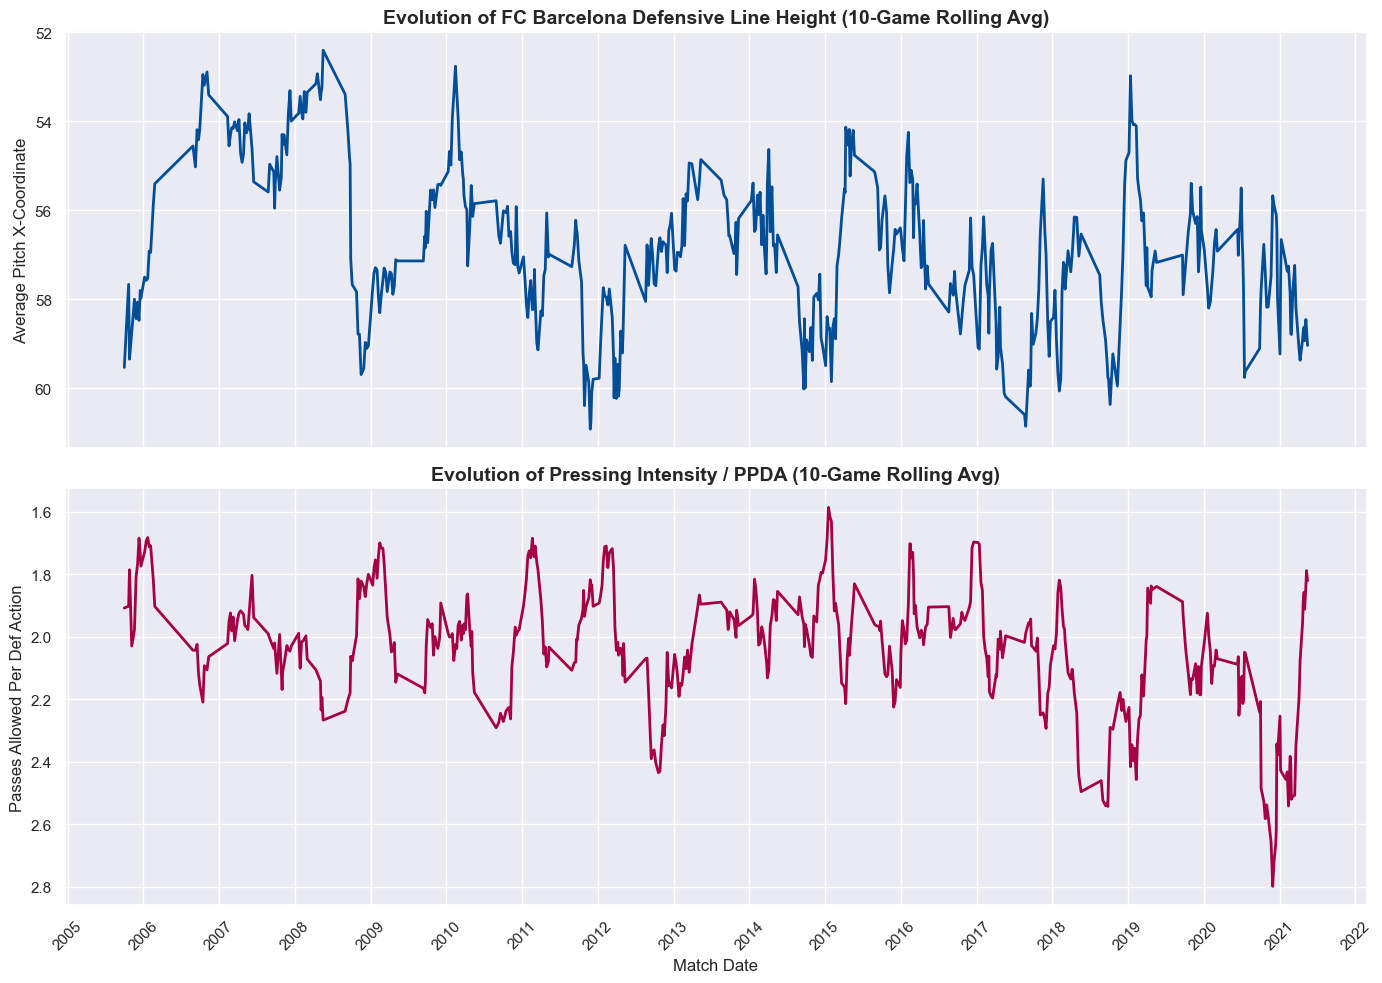

✅ Visualizations Complete!


In [ ]:
# Cell 6: 15-Year Time-Series Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

print("Generating Tactical Timelines...")

df = pd.read_csv("barcelona_match_tactics.csv")
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date')

# Calculate a 10-game rolling average to smooth out the charts
df['def_line_rolling'] = df['def_line_height'].rolling(window=10, min_periods=1).mean()
df['ppda_rolling'] = df['ppda'].rolling(window=10, min_periods=1).mean()

# Set up the visual canvas
sns.set_theme(style="darkgrid", context="notebook")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Chart 1: Defensive Line Height
sns.lineplot(data=df, x='match_date', y='def_line_rolling', ax=axes[0], color='#004D98', linewidth=2)
axes[0].set_title('Evolution of FC Barcelona Defensive Line Height (10-Game Rolling Avg)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Pitch X-Coordinate', fontsize=12)
axes[0].invert_yaxis() # Invert so higher up the pitch (closer to 120) is visually "higher" on the graph

# Chart 2: PPDA (Pressing Intensity)
sns.lineplot(data=df, x='match_date', y='ppda_rolling', ax=axes[1], color='#A50044', linewidth=2)
axes[1].set_title('Evolution of Pressing Intensity / PPDA (10-Game Rolling Avg)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Passes Allowed Per Def Action', fontsize=12)
axes[1].invert_yaxis() # Invert so a LOWER PPDA (more intense press) is visually "higher" on the graph

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.xlabel('Match Date', fontsize=12)

plt.tight_layout()
plt.show()
print("Visualizations Complete!")